# Variational Autoencoder (VAE) - MNIST Digit Generation

A Variational Autoencoder (VAE) is a generative model that learns the probability distribution of input data and can generate new similar data.

It consists of:
- Encoder → Converts input into latent distribution (mean and variance)
- Decoder → Reconstructs data from latent space

## How VAE Works

1. Input image is passed to encoder
2. Encoder outputs mean (μ) and log variance (log σ²)
3. Latent vector z is sampled using reparameterization trick
4. Decoder reconstructs image from z
5. Loss = Reconstruction Loss + KL Divergence

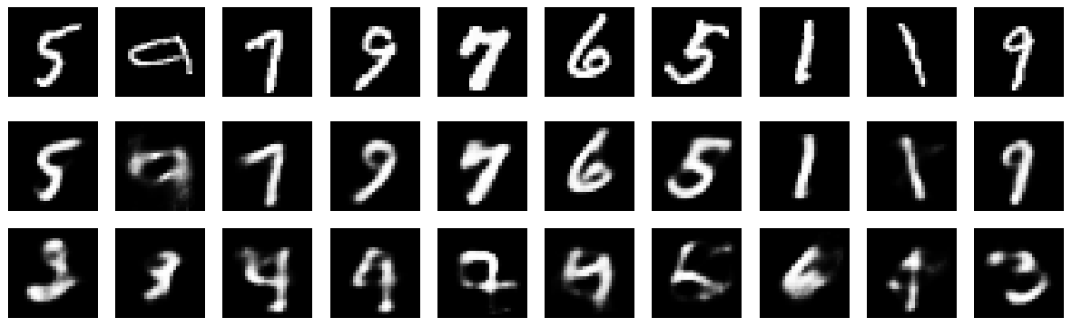

In [1]:
!pip install torch torchvision matplotlib numpy

In [2]:
# import libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

from torch.utils.data import dataloader
import matplotlib.pyplot as plt
import numpy as np



In [10]:
# Encoder class, which maps input data to the latent space

class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    """
    Initialize the Encoder class.

    Args:

    input_dim: dimension of the input data
    hidden_dim: dimension of the hidden layer
    latent_dim: dimension of the latent space
    """

    super(Encoder, self).__init__()

    #define fully connected layers
    self.fc1 = nn.Linear(input_dim, hidden_dim) #layer connection 1
    self.fc_mu = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

  #define the forward pass through the Encoder
  def forward(self, x):
    """
    Define the forward pass through the Encoder.

    Args:

    x: input data

    Returns:
    mu: the mean of the latent space.
    logvar: the log variance of the latent space.
    """

    #apply ReLU activation to hidden layer

    h = torch.relu(self.fc1(x))

    #calculate Mu and Logvar
    mu = self.fc_mu(h)

    logvar = self.fc_logvar(h)

    return mu, logvar


In [11]:
#Define the decoder class, which maps latent space to output

class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    """
    Initialize the decoder class

    Args:
    latent_dim: dimension of the latent space
    hidden_dim: dimension of the hidden layer
    output_dim: dimension of the output data

    """
    super(Decoder, self).__init__()

    #define fully connected layers for decoder

    self.fc1 = nn.Linear(latent_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, output_dim)


  #define the forward pass through for the decoder

  def forward(self, z):
    """
    Define the forward pass through the decoder

    Args:
    z: the latent space data.

    Returns:
    x_hat: the reconstructed output data.
    """

    #apply ReLU activation to the hidden layer
    #relu is used to takle non linearity of data.

    h = torch.relu(self.fc1(z))

    #apply sigmoid activation to output layer
    x_hat = torch.sigmoid(self.fc2(h))

    return x_hat



In [12]:
#Define the variational autoencoder VAE class

class VAE(nn.Module):

  def __init__(self, input_dim, hidden_dim, latent_dim):
    """
    Initialize the VAE Class

    Args:
    input_dim: dimension of the input data
    hidden_dim: dimension of the hidden layer
    latent_dim: dimension of the latent space
    """

    super(VAE, self).__init__()

    #Define Encoder and Decoder instances
    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
    self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

  def forward(self, x):
    """
    Define the forward pass through the VAE.

    Args:
    x: input data

    Returns:
    x_hat: the reconstructed output data.
    mu: the mean of the latent space.
    logvar: the log variance of the latent space.
    """

    #Encode input to the latent space
    mu, logvar = self.encoder(x)

    #sample from latent space using reparameterizatoin trick

    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)

    z = mu + eps*std


    #decode latent space to output
    x_hat = self.decoder(z)

    return x_hat, mu, logvar



In [13]:
def loss_function(x, x_hat, mu, logvar):
  """
  Define the loss functoin for the VAE

  Args:
  x: input data
  x_hat: the reconstructed output data.
  mu: the mean of the latent space.
  logvar: the log variance of the latent space.

  Returns:
  loss: the VAE loss.
  """

  #Calculate Binary Cross-Entropy loss
  BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

  #Calculate KL = kullback-leibler divergence loss
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

  return BCE + KLD


In [14]:
input_dim = 784
hidden_dim = 400
latent_dim = 20

lr = 1e-3 # learning rate
batch_size = 128
epochs = 10


# Create Data loaders and load data

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])

train_dataset = datasets.MNIST(root='./data', train=True, download = True, transform= transform)

train_loader = dataloader.DataLoader(train_dataset, batch_size=batch_size, shuffle = True)



In [15]:
# instanciate the model and optimizer

vae= VAE(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)



# Training loop --> 10 loops

for epoch in range(epochs):
  train_loss = 0

  for x, _ in train_loader:
    # we are transforming image to 1D array
    x = x.view(-1, input_dim) # (-1, 784)

    optimizer.zero_grad()

    x_hat, mu, logvar = vae(x)

    loss = loss_function(x, x_hat, mu, logvar)

    loss.backward()

    optimizer.step()

    train_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader.dataset)}")

Epoch 1, Loss: 164.08289576822918
Epoch 2, Loss: 121.26758780924479
Epoch 3, Loss: 114.40195460611979
Epoch 4, Loss: 111.46192392578125
Epoch 5, Loss: 109.81804521484375
Epoch 6, Loss: 108.61142960611978
Epoch 7, Loss: 107.78881183268228
Epoch 8, Loss: 107.1607022623698
Epoch 9, Loss: 106.60242670898438
Epoch 10, Loss: 106.19993092447916


# Testing and Evaluation of the model

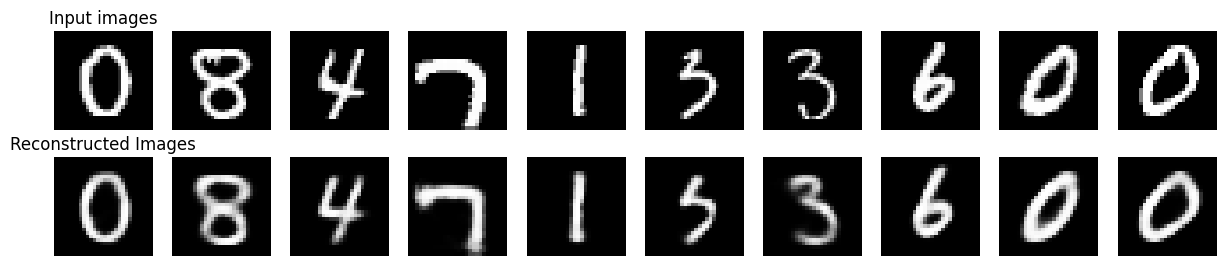

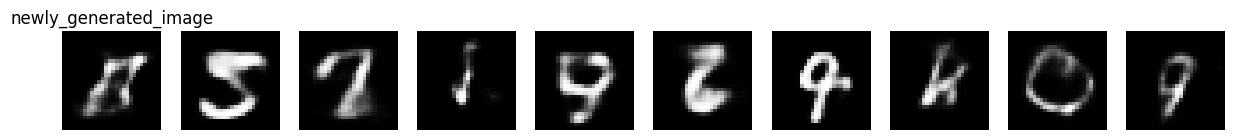

In [16]:
vae.eval()

# Reconstructing of the input data

with torch.no_grad():

  # loaded input image data

  x, _ = next(iter(train_loader))

  x = x.view(-1, input_dim) # (-1, 784)


  x_hat, _, _ = vae(x)

  x = x.view(-1, 28, 28) # 28*28 2D Image

  x_hat = x_hat.view(-1, 28, 28) # Reconstructed input image, and not newly generate image

  fig, axs = plt.subplots(2, 10, figsize = (15, 3))

  for i in range(10):

    axs[0, i].imshow(x[i].cpu().numpy(), cmap = 'gray')

    axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap = 'gray')


    axs[0,i].axis('off')

    axs[1,i].axis('off')

    # Assign row names
    axs[0, 0].set_title('Input images')  # Assigning 'a' to the first row
    axs[1, 0].set_title('Reconstructed Images')

  plt.show()



# Visualizing newly generated data

# Generative AI Part


with torch.no_grad():

  z = torch.randn(10, latent_dim)

  newly_generated_image = vae.decoder(z) # (-1, 784)

  newly_generated_image = newly_generated_image.view(-1, 28, 28) # (28, 28)

  fig, axs = plt.subplots(1, 10, figsize = (15, 3))

  for i in range(10):

    axs[i].imshow(newly_generated_image[i].cpu().numpy(), cmap='gray')

    axs[i].axis('off')

    axs[0].set_title('newly_generated_image')

  plt.show()



## Observations

- Reconstructed images are similar but slightly blurred
- VAE learns general patterns instead of exact pixels
- Generated images show new digit variations
- Increasing epochs improves results